In [618]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [619]:
df = pd.read_csv('loan_approval_dataset.csv')

In [620]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [621]:
df.columns = df.columns.str.strip()

In [622]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [623]:
df.isna().sum().sort_values(ascending=False)

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [624]:
df.drop("loan_id", axis=1, inplace=True)

In [625]:
df.columns = [
    'dependents',
    'education',
    'self_employed',
    'annual_income',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets',
    'commercial_assets',
    'luxury_assets',
    'bank_assets',
    'loan_status'
]

In [626]:
str_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols = df.select_dtypes(include='number').columns.tolist()


In [627]:
df['loan_status'].value_counts(normalize=True)

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

<Axes: xlabel='loan_status', ylabel='count'>

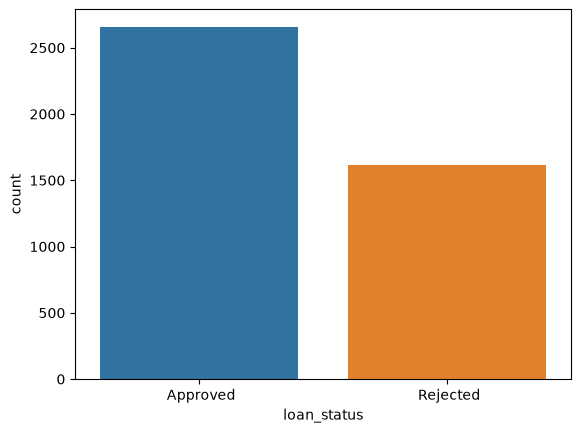

In [612]:
sns.countplot(data=df,x = df['loan_status'],hue='loan_status')

<Axes: xlabel='annual_income', ylabel='Density'>

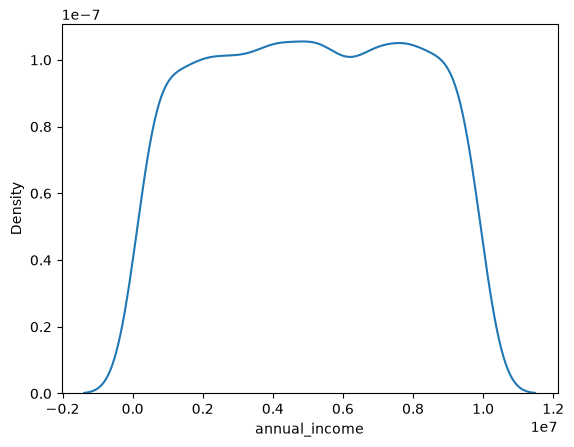

In [614]:
sns.kdeplot(data=df,x=df['annual_income'])

In [ ]:
for col in str_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())

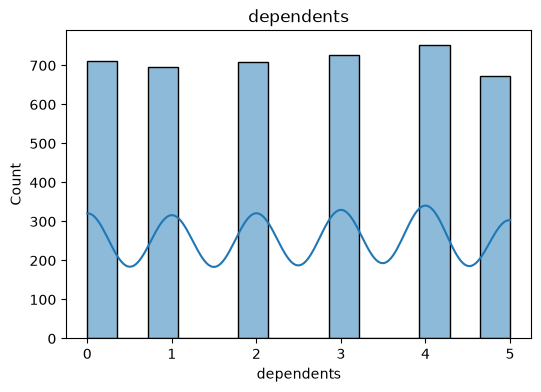

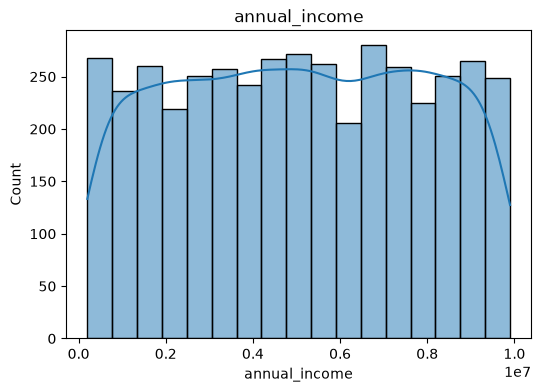

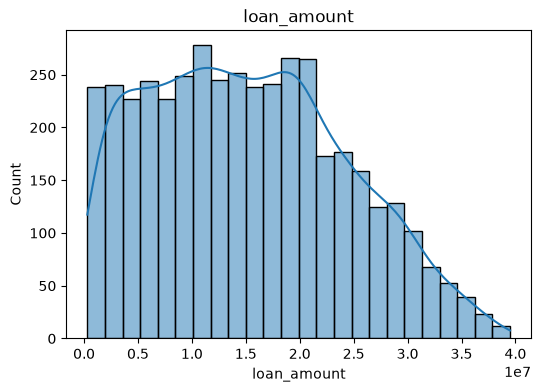

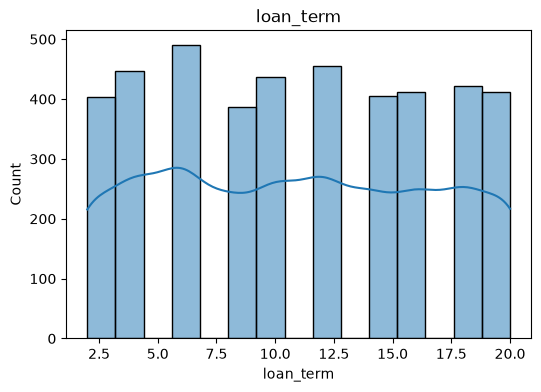

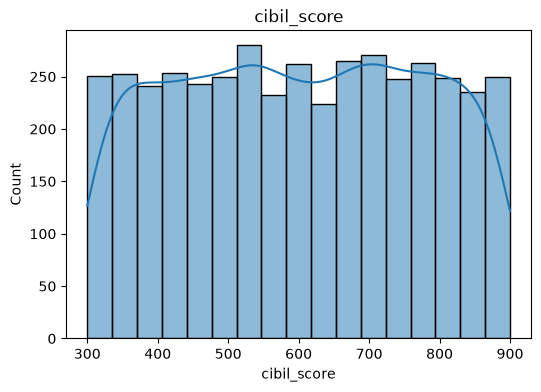

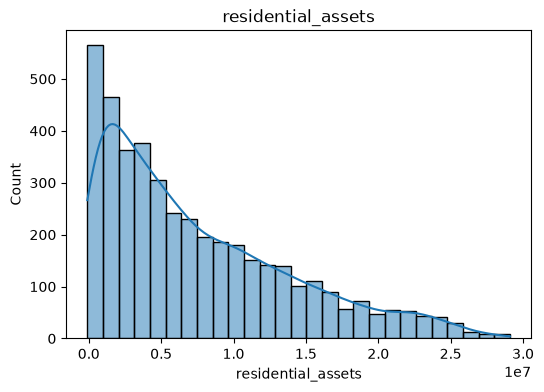

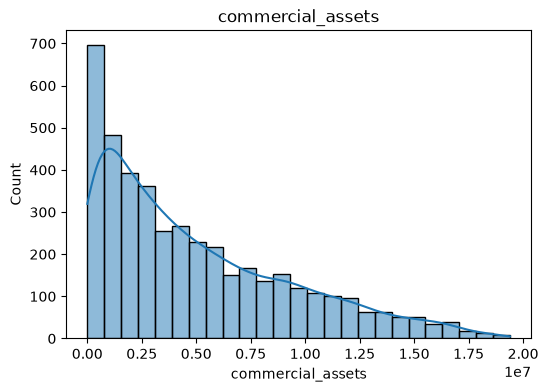

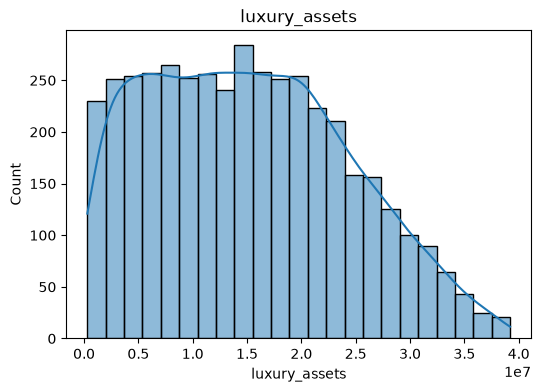

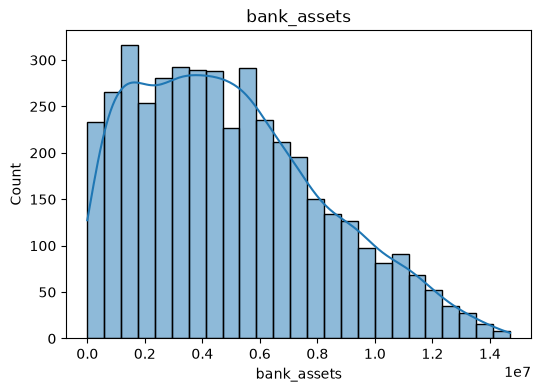

In [628]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

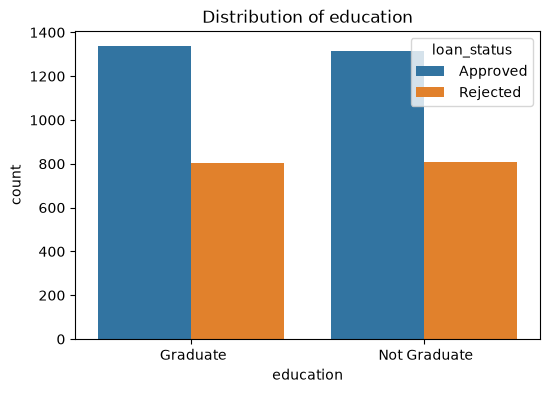

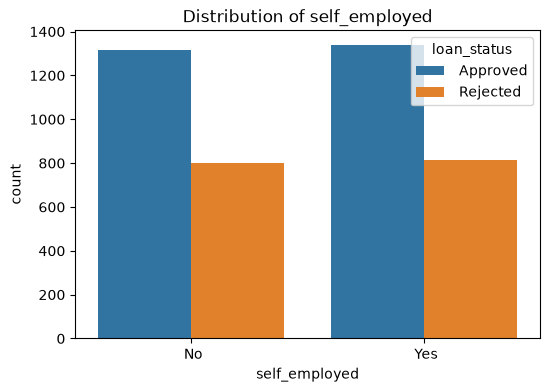

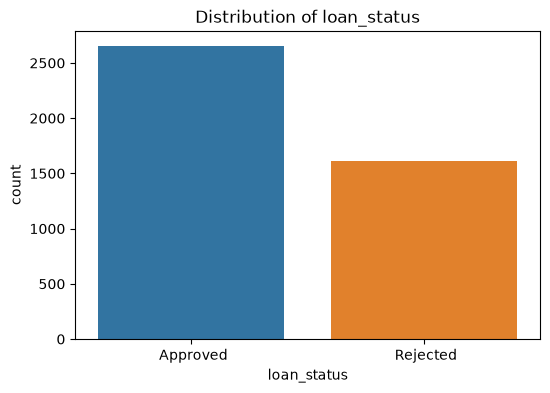

In [629]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in str_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,hue='loan_status'
    )

    plt.title(f"Distribution of {col}")
    plt.show()

In [630]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   dependents          4269 non-null   int64
 1   education           4269 non-null   str  
 2   self_employed       4269 non-null   str  
 3   annual_income       4269 non-null   int64
 4   loan_amount         4269 non-null   int64
 5   loan_term           4269 non-null   int64
 6   cibil_score         4269 non-null   int64
 7   residential_assets  4269 non-null   int64
 8   commercial_assets   4269 non-null   int64
 9   luxury_assets       4269 non-null   int64
 10  bank_assets         4269 non-null   int64
 11  loan_status         4269 non-null   str  
dtypes: int64(9), str(3)
memory usage: 400.3 KB


In [631]:
str_cols

['education', 'self_employed', 'loan_status']

In [632]:
numeric_cols

['dependents',
 'annual_income',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets',
 'commercial_assets',
 'luxury_assets',
 'bank_assets']

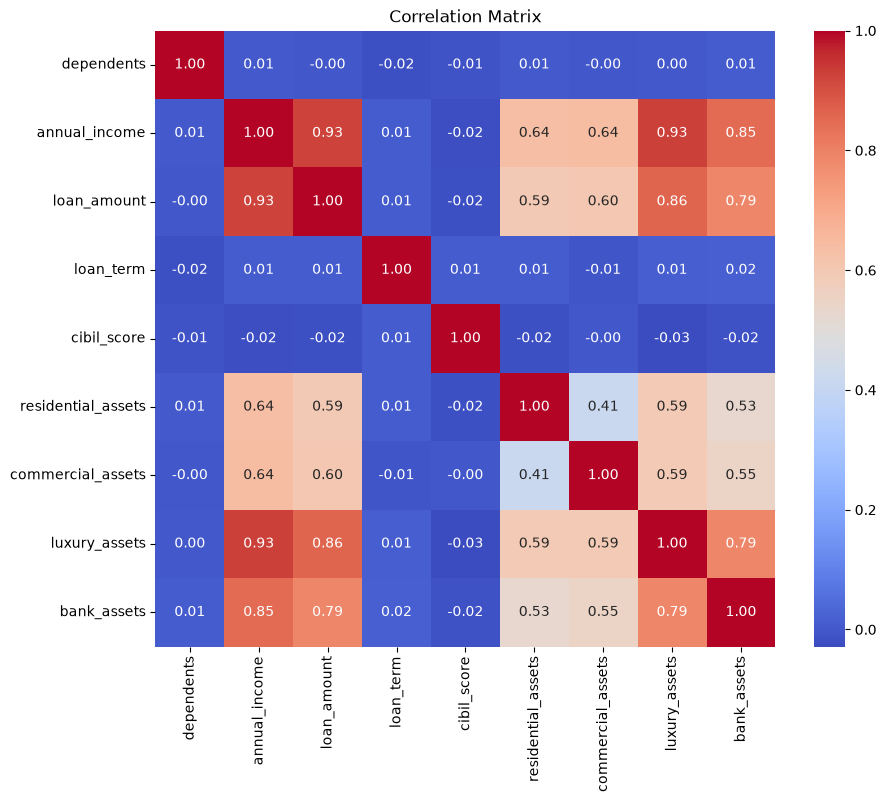

In [633]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

In [635]:
np.average(df['loan_term'])

np.float64(10.900445069102835)

In [636]:
df.shape

(4269, 12)

In [638]:
df.columns

Index(['dependents', 'education', 'self_employed', 'annual_income',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets',
       'commercial_assets', 'luxury_assets', 'bank_assets', 'loan_status'],
      dtype='str')

In [639]:
str_cols

['education', 'self_employed', 'loan_status']

In [640]:
average_income = np.round(np.mean(df['annual_income']))

In [641]:
from num2words import num2words as n2w

In [642]:
n2w(average_income)

'five million, fifty-nine thousand, one hundred and twenty-four'

In [643]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
annual_income,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_assets,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [644]:
df['annual_income'].min(),df['annual_income'].max()

(np.int64(200000), np.int64(9900000))

In [645]:
n2w(df['annual_income'].max())

'nine million, nine hundred thousand'

In [646]:
loan_term_mean = np.mean(df['loan_term'])

In [647]:
f'Average loan years {n2w(round(loan_term_mean))} years'

'Average loan years eleven years'

In [648]:
numeric_cols

['dependents',
 'annual_income',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets',
 'commercial_assets',
 'luxury_assets',
 'bank_assets']

In [649]:
str_cols

['education', 'self_employed', 'loan_status']

In [650]:
from sklearn.preprocessing import StandardScaler

In [652]:
scaler = StandardScaler()

In [653]:
df

,dependents,education,self_employed,annual_income,loan_amount,loan_term,cibil_score,residential_assets,commercial_assets,luxury_assets,bank_assets,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [654]:
from sklearn.model_selection import train_test_split

In [656]:
X = df.drop('loan_status',axis=1)

In [658]:
y = df['loan_status']

In [660]:
X_train,X_test,y_train,y_test = train_test_split(X,y
                                                 ,test_size=0.2,random_state=42,stratify=y)

In [664]:
str_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

print(str_cols)
print(numeric_cols)

['education', 'self_employed']
['dependents', 'annual_income', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets', 'commercial_assets', 'luxury_assets', 'bank_assets']


In [665]:
str_cols[:-1]

['education']

In [666]:
X_train = pd.get_dummies(
    X_train,
    columns=str_cols,
    drop_first=True
)

In [667]:
X_test = pd.get_dummies(
    X_test,
    columns=str_cols,
    drop_first=True
)

In [668]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [669]:

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

In [671]:


X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

In [672]:
y_train = y_train.map({
    " Approved":1,
    " Rejected":0
})


In [673]:

y_test = y_test.map({
    " Approved":1,
    " Rejected":0
})

In [676]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC

In [ ]:
logistic_model = LogisticRegressionCV(
    cv=3,fit_intercept=True
)